# This notebook shows how to compute vertical tunnelling transport through a 2D material
### Import the necessary libraries

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from elkpy.structure import Structure

### What gets through, rather than what the tip sees
An electron enters at a point $\mathbf{r}$ above the sheet and leaves into an infinite metallic substrate below it, so the current is set by the *nonlocal* Green's function between the two, not by the local density of states at the tip:
$$ T(\mathbf{r};E) = \int_{\rm plane} |G(\mathbf{r},\mathbf{r}';E)|^2\,d^2r', \qquad G(\mathbf{r},\mathbf{r}') = \sum_{n\mathbf{k}} \frac{\psi_{n\mathbf{k}}(\mathbf{r})\,\psi^*_{n\mathbf{k}}(\mathbf{r}')}{E-\varepsilon_{n\mathbf{k}}+i\eta} $$
The band sum happens *before* the modulus: different bands are different routes through the material and they add as amplitudes.

### The substrate makes the $k$-sum incoherent
A substrate invariant under every lateral lattice translation conserves the lateral momentum, so only bands at the *same* $\mathbf{k}$ interfere. What survives is one Hermitian Gram matrix per $k$-point and one quadratic form:
$$ S_{\mathbf{k}}[n,n'] = \int_{\rm plane}\psi^*_{n\mathbf{k}}\psi_{n'\mathbf{k}}\,d^2r', \qquad T(\mathbf{r};E) = \sum_{\mathbf{k}} w_{\mathbf{k}} \sum_{nm} a_n(\mathbf{r})\,a^*_m(\mathbf{r})\,S_{\mathbf{k}}[n,m] $$
with $a_n = \psi_{n\mathbf{k}}(\mathbf{r})\sqrt{\delta_\eta(E-\varepsilon_{n\mathbf{k}})/\eta}$ the on-shell tip amplitude and $\eta$ the energy window the leads let states through in.

### Monolayer graphene
The tip plane sits 2.4 Bohr above the sheet and the substrate plane the same distance below it, both in the vacuum.

In [2]:
B = 1 / 0.529177210903
A, C = 2.46 * B, 20.0
AVEC = [(A, 0, 0), (-A / 2, A * 3**0.5 / 2, 0), (0, 0, C)]

mono = Structure(AVEC, {"C": [(0, 0, 0.5), (1 / 3, 2 / 3, 0.5)]}).get_calculation(
    "_scratch/graphene_transport", xc="PW", ngridk=(6, 6, 1), rgkmax=7.0,
    # tshift: mandatory. Elk otherwise moves the origin onto the inversion
    # centre (for a honeycomb, the bond midpoint) while both planes stay here
    extra_blocks={"tshift": [False], "nempty": [10]})
mono.get_energy()

-75.621080803548

### The transport map, and the tunnelling image at the same plane
`exit_region="cell"` widens the substrate from a plane to the whole cell, which makes $S_{\mathbf{k}}$ the identity and turns the same expression into the Tersoff-Hamann local density of states -- the picture an STM sees.

In [3]:
# kgrid is generated by the task itself, so it is independent of ngridk. It
# must be a multiple of 3: graphene's states at E_F are all at K, and a mesh
# without K gives a map that is identically zero rather than merely small
geom = dict(exit_height=0.38, height=0.62, grid=(24, 24), kgrid=(6, 6, 1),
            broadening=0.005)
flow = mono.get_vertical_transport(**geom)
local = mono.get_vertical_transport(exit_region="cell", incoherent=False, **geom)
print("open substrate channels", round(flow["channels"], 6),
      " weight off the diagonal of S", round(flow["offdiagonal_weight"], 8))

open substrate channels 2.0  weight off the diagonal of S 0.0


correlation between the two maps: 1.000000


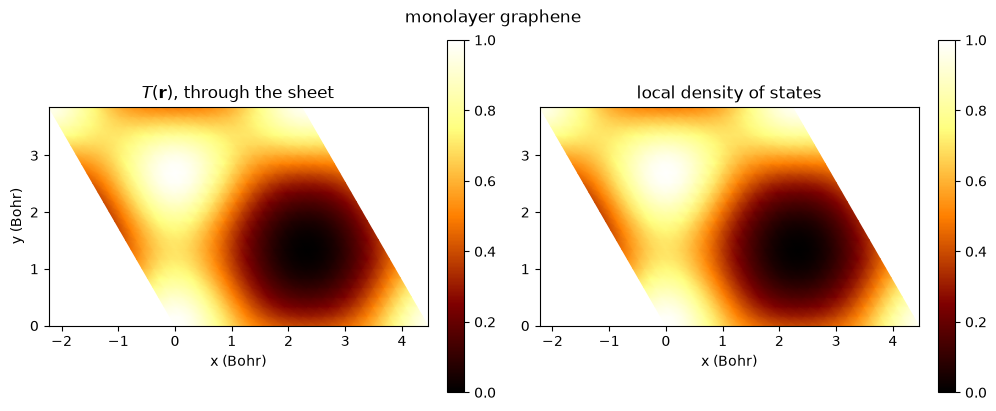

In [4]:
def show(res, loc, title):
    n2, n1 = res["grid"]
    x, y = (res["points"][:, i].reshape(n2, n1) for i in (0, 1))
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
    for ax, f, lab in [(axes[0], res["transmission"][0], "$T(\\mathbf{r})$, through the sheet"),
                       (axes[1], loc["transmission"][0], "local density of states")]:
        im = ax.pcolormesh(x, y, f.reshape(n2, n1) / f.max(), shading="gouraud", cmap="afmhot")
        fig.colorbar(im, ax=ax); ax.set(title=lab, xlabel="x (Bohr)", aspect="equal")
    axes[0].set_ylabel("y (Bohr)")
    fig.suptitle(title)
    r = np.corrcoef(res["transmission"][0], loc["transmission"][0])[0, 1]
    print(f"correlation between the two maps: {r:.6f}")

show(flow, local, "monolayer graphene")

### For one sheet the two pictures agree, and that is a theorem
The states at $E_F$ are the Dirac doublet at $K$. The symmetry the tip/substrate geometry leaves intact is $C_{3v}$ -- its mirror $\sigma_v$ exchanges the two sublattices *without* flipping $z$ -- so the doublet is still an irreducible 2D representation and by Schur's lemma $S_K$ is a multiple of the identity. The substrate cannot tell the two partners apart, so there is nothing off-diagonal for the current to interfere through.

### AB-stacked bilayer graphene
Now the element exchanging the two zero-energy states is an in-plane $C_2'$, which *flips* $z$ and is broken by having a tip above and a substrate below. The intact group is $C_3$ alone, which is abelian: the two states are the non-dimer sites of the two different layers, and the substrate sees them through very different amounts of carbon.

In [5]:
D, CB = 3.35 * B, 32.0          # graphite interlayer spacing; do not relax this
Z1, Z2 = 0.5 - D / (2 * CB), 0.5 + D / (2 * CB)
GAP = 2.5 / CB                  # the same standoff above and below, so only the substrate differs
BI_AVEC = [(A, 0, 0), (-A / 2, A * 3**0.5 / 2, 0), (0, 0, CB)]

bi = Structure(BI_AVEC, {"C": [(0, 0, Z1), (1 / 3, 2 / 3, Z1),
                               (1 / 3, 2 / 3, Z2), (2 / 3, 1 / 3, Z2)]}).get_calculation(
    "_scratch/bilayer_transport", xc="PW", ngridk=(6, 6, 1), rgkmax=7.0,
    extra_blocks={"tshift": [False], "nempty": [12]})
bi.get_energy()

-151.24526904756

correlation between the two maps: 0.805428
weight off the diagonal of S: 0.5012


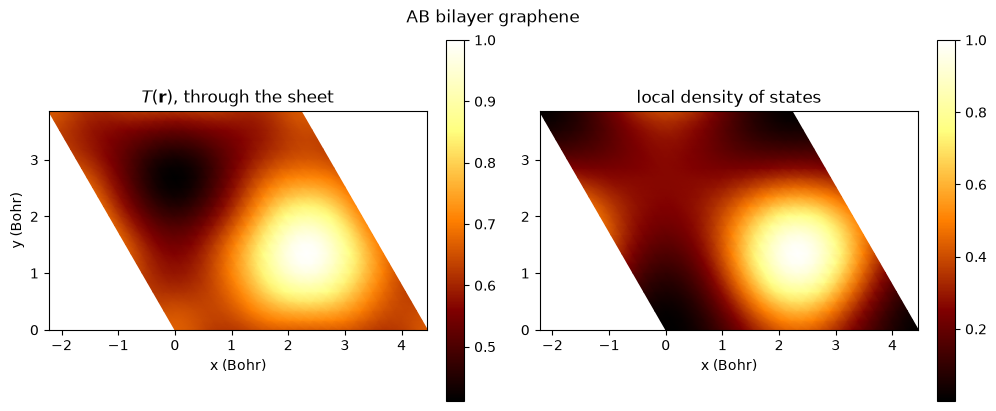

In [6]:
bigeom = dict(exit_height=Z1 - GAP, height=Z2 + GAP, grid=(24, 24),
              kgrid=(6, 6, 1), broadening=0.005)
biflow = bi.get_vertical_transport(**bigeom)
bilocal = bi.get_vertical_transport(exit_region="cell", incoherent=False, **bigeom)
show(biflow, bilocal, "AB bilayer graphene")
print("weight off the diagonal of S:", round(biflow["offdiagonal_weight"], 4))

### What separates them: the substrate's two channels at $K$
The eigenvalues of $S_K$ are how strongly the substrate couples to each member of the degenerate pair. Equal for the monolayer (Schur), and orders of magnitude apart for the bilayer, whose states are layer-polarized.

monolayer ratio 1.0000017   bilayer ratio 1311


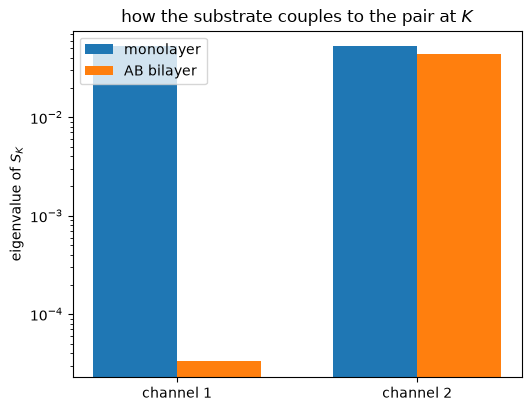

In [7]:
def channels_at_k(calc, **geom):
    """The eigenvalues of S_K for the pair at the Fermi level. A 3x3 mesh
    contains K, and the narrow window admits only that pair."""
    raw = calc.get_vertical_transport(kgrid=(3, 3, 1), broadening=0.002,
                                      window=(-0.004, 0.004), **geom)["raw"]
    s = next(o for o in raw["overlaps"] if o.shape[0] > 0)
    return np.linalg.eigvalsh(0.5 * (s + s.conj().T))

mono_ch = channels_at_k(mono, exit_height=0.38, height=0.62, grid=(6, 6))
bi_ch = channels_at_k(bi, exit_height=Z1 - GAP, height=Z2 + GAP, grid=(6, 6))

fig, ax = plt.subplots(figsize=(5.2, 4), constrained_layout=True)
w, pos = 0.35, np.arange(2)
ax.bar(pos - w / 2, sorted(mono_ch)[:2], w, label="monolayer")
ax.bar(pos + w / 2, sorted(bi_ch)[:2], w, label="AB bilayer")
ax.set(yscale="log", xticks=pos, xticklabels=["channel 1", "channel 2"],
       ylabel=r"eigenvalue of $S_K$", title="how the substrate couples to the pair at $K$")
ax.legend()
print(f"monolayer ratio {max(mono_ch)/min(mono_ch):.7f}   bilayer ratio {max(bi_ch)/min(bi_ch):.4g}")